# Phase 4: Forecast-Based Trading and Stochastic Adoption

Goal: turn the AR forecast into a tradeable rule, let agents adopt it via stochastic diffusion (equations 11 and 12), and watch what happens to the forecast as more agents act on it. Compares zero, slow, and fast diffusion regimes on paired shocks.

Reference: section 3.4 of the proposal for the AR rule, section 3.5 for stochastic diffusion, section 3.6 for the intra-period timing and the two evaluation channels, and section 4.1 for the realised-return and demand-adjusted-return R^2 endpoints.

**Central dual-channel result.** This is the first phase where the proposal's two evaluation channels diverge on the same path. Against realised returns, the rolling forecast becomes *more* accurate as adoption rises (self-fulfilling channel: adopter demand pushes realised returns in the forecast direction). Against the demand-adjusted return `x_{t+1} = r_{t+1} - mu D_t`, the same forecast becomes *less* accurate (demand-adjusted-erosion channel: the rolling fit picks up the amplified empirical autocorrelation and over-predicts the underlying demand-adjusted process). Both readings are reported on equal footing as primary endpoints. The realised reading is the metric a deployed forecaster actually computes; the demand-adjusted reading is the counterfactual that asks whether the independent signal survives once self-fulfilment is stripped out. Note that the demand-adjusted return is a counterfactual, not the full regression residual (which would be `sigma * epsilon = r - phi*r_lag - mu*D`).

In [1]:
# Number of traders.
N = 200

# Number of periods. Long enough that both diffusion regimes can ramp from
# A=0 (at metric warm-up) to near saturation inside the observable window.
T = 8000

# Market-maker price-impact coefficient (equation 5).
mu = 0.05

# Reduced-form AR(1) coefficient in the return law (equation 6).
phi = 0.25

# Standard deviation of exogenous news shocks.
sigma_news = 0.01

# Standard deviation of individual null orders (equation 8).
sigma_q = 1.0

# Rolling AR window and order for the public forecast.
forecast_window = 250
forecast_p = 1

# Combined risk-aversion times perceived variance, the denominator in (1) and (3).
risk_scale = 0.001

# Per-trader position cap from equation (3). Kept modest so adopter impact is
# comparable to phi r_t in magnitude rather than dominating it.
q_cap = 0.05

# Trailing window for rolling forecast metrics and rolling effective phi.
eval_window = 1000

# Hold adoption at zero until the rolling metrics have just become finite,
# then release the diffusion. Without this delay, adoption ramps during the
# warm-up and the fast regime saturates before the first metric observation,
# leaving no low-adoption samples to compare against the high-adoption tail.
adoption_start_t = forecast_window + eval_window

# Seed shared by all regimes so demand and news shocks are paired across them.
seed = 71

# Extended horizon for the saturation-diagnostic figures. T_long is large
# enough that fast diffusion has thousands of post-saturation periods so
# the rolling forecaster fully equilibrates with phi_effective in the
# saturated regime. n_seeds_mc_saturation controls the Monte Carlo band
# for the saturation figure.
T_long = 30000
n_seeds_mc_saturation = 50
mc_saturation_base_seed = 5000  # distinct from seed=71 and mc_base_seed=1000

# Output paths.
fig_dir = "../results/figures"
data_dir = "../results/data"

# Stochastic diffusion regimes (equation 11). Onset is held off until
# adoption_start_t = 1250, so each regime starts ramping from A=0 at the
# moment metrics first become finite. Slow then sweeps roughly A=0 to
# A=0.87 across the run, fast sweeps A=0 to saturation inside the same
# window.
regimes = [
    {"name": "zero adoption",   "pi": 0.0,    "delta": 0.0, "colour": "C0"},
    {"name": "slow diffusion",  "pi": 3e-4,   "delta": 0.0, "colour": "C1"},
    {"name": "fast diffusion",  "pi": 1e-3,   "delta": 0.0, "colour": "C3"},
]

In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from reflexive_market import simulate
from reflexive_market.metrics import rolling_oos_r2, rolling_phi

In [3]:
results = []
for regime in regimes:
    rng = np.random.default_rng(seed)
    out = simulate.run(
        T=T, N=N, mu=mu, phi=phi,
        sigma_news=sigma_news, sigma_q=sigma_q,
        rng=rng,
        forecast_window=forecast_window, forecast_p=forecast_p,
        risk_scale=risk_scale, q_cap=q_cap,
        adoption_pi=regime["pi"], adoption_delta=regime["delta"],
        adoption_start_t=adoption_start_t,
    )
    # Demand-adjusted return per section 3.6 of the proposal: the part of
    # r_{t+1} that is not the contemporaneous adopter demand impact. R^2
    # against this isolates how well the forecast tracks the underlying
    # AR + news component once the self-fulfilment channel is stripped out.
    # It is a counterfactual, not the full regression residual.
    demand_adjusted = out["returns"] - mu * out["demand"]
    out["demand_adjusted"] = demand_adjusted
    out["rolling_oos_r2_realised"] = rolling_oos_r2(out["returns"], out["forecasts"], eval_window)
    out["rolling_oos_r2_da"] = rolling_oos_r2(demand_adjusted, out["forecasts"], eval_window)
    out["rolling_phi"] = rolling_phi(out["returns"], eval_window)
    results.append({**regime, **out})

In [4]:
# Summarise low-adoption vs high-adoption performance per regime. The low
# window picks up a span where the rolling fit is past warm-up but adoption
# has barely moved; the high window picks up the latest period where
# adoption has saturated (or, for zero adoption, simply the late span).
warmup = forecast_window + eval_window
low_lo, low_hi = warmup, warmup + 1500
high_lo, high_hi = T - 1500, T

print(f"input phi:  {phi:+.4f}    risk_scale: {risk_scale:.4f}    q_cap: {q_cap:.4f}")
print()
header = (
    f"{'regime':<18}{'A_low':>7}{'A_high':>9}"
    f"{'R2real_lo':>11}{'R2real_hi':>11}"
    f"{'R2da_lo':>10}{'R2da_hi':>10}"
    f"{'phi_lo':>9}{'phi_hi':>9}"
)
print(header)
for r in results:
    A_low = float(np.nanmean(r["adoption_share"][low_lo:low_hi]))
    A_high = float(np.nanmean(r["adoption_share"][high_lo:high_hi]))
    R2r_low = float(np.nanmean(r["rolling_oos_r2_realised"][low_lo:low_hi]))
    R2r_high = float(np.nanmean(r["rolling_oos_r2_realised"][high_lo:high_hi]))
    R2x_low = float(np.nanmean(r["rolling_oos_r2_da"][low_lo:low_hi]))
    R2x_high = float(np.nanmean(r["rolling_oos_r2_da"][high_lo:high_hi]))
    phi_low = float(np.nanmean(r["rolling_phi"][low_lo:low_hi]))
    phi_high = float(np.nanmean(r["rolling_phi"][high_lo:high_hi]))
    r["summary"] = (A_low, A_high, R2r_low, R2r_high, R2x_low, R2x_high, phi_low, phi_high)
    print(
        f"{r['name']:<18}{A_low:>7.3f}{A_high:>9.3f}"
        f"{R2r_low:>11.4f}{R2r_high:>11.4f}"
        f"{R2x_low:>10.4f}{R2x_high:>10.4f}"
        f"{phi_low:>9.4f}{phi_high:>9.4f}"
    )

input phi:  +0.2500    risk_scale: 0.0010    q_cap: 0.0500

regime              A_low   A_high  R2real_lo  R2real_hi   R2da_lo   R2da_hi   phi_lo   phi_hi
zero adoption       0.000    0.000     0.0695     0.0653    0.0821    0.0676   0.2821   0.2776
slow diffusion      0.214    0.836     0.0763     0.1651    0.0780    0.0471   0.2936   0.4177
fast diffusion      0.505    0.994     0.0942     0.1904    0.0712    0.0386   0.3205   0.4470


## Adoption trajectories

Each regime is a different per-period switch probability pi, with no exit. Adoption transitions are held off until t = forecast_window + eval_window so each regime starts ramping from A=0 at the moment rolling metrics first become finite. With pi=0 the share stays at zero; the slow rate produces a gentle climb sweeping roughly A=0 to A=0.87 over the run; the fast rate climbs sharply, reaching saturation around mid-run and giving the high-adoption tail.

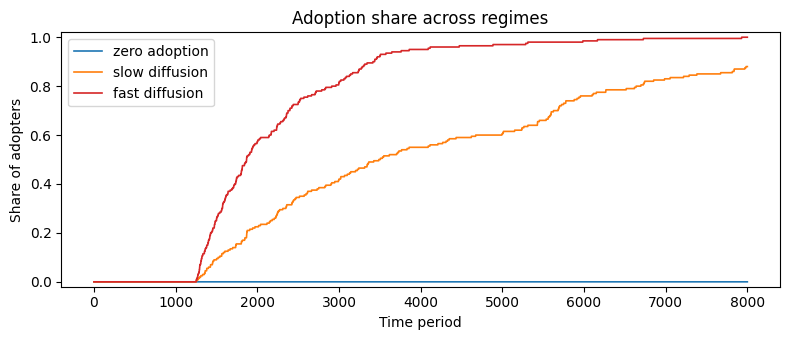

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for r in results:
    ax.plot(r["adoption_share"], color=r["colour"], linewidth=1.2, label=r["name"])
ax.set_title("Adoption share across regimes")
ax.set_xlabel("Time period")
ax.set_ylabel("Share of adopters")
ax.set_ylim(-0.02, 1.02)
ax.legend()
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_adoption_share.png", dpi=150)
plt.show()

## Rolling OOS R^2 over time, both views

Same single-seed paired-shock example, plotted as a time series instead of against adoption share. Three panels stacked vertically: rolling realised-return OOS R^2 (top), rolling demand-adjusted OOS R^2 (middle), and adoption share (bottom). The two R^2 readings of the same forecast cross over each other once adoption has ramped up: realised R^2 climbs while demand-adjusted R^2 falls. The adoption-share panel underneath makes it visually obvious which time spans correspond to low- vs high-adoption regimes for each diffusion rate.

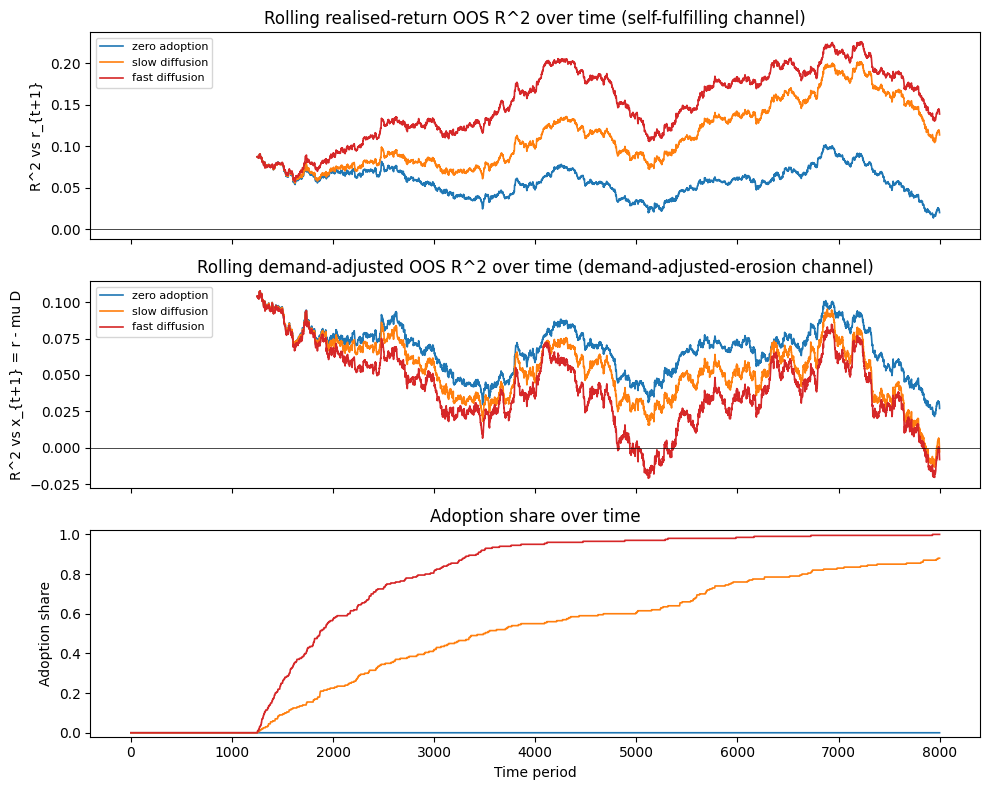

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for r in results:
    yr = r["rolling_oos_r2_realised"]
    yx = r["rolling_oos_r2_da"]
    A = r["adoption_share"]
    t = np.arange(len(yr))
    mask_r = np.isfinite(yr)
    mask_x = np.isfinite(yx)
    axes[0].plot(t[mask_r], yr[mask_r], color=r["colour"], linewidth=1.2, label=r["name"])
    axes[1].plot(t[mask_x], yx[mask_x], color=r["colour"], linewidth=1.2, label=r["name"])
    axes[2].plot(t, A, color=r["colour"], linewidth=1.2, label=r["name"])
axes[0].axhline(0.0, color="k", linewidth=0.5)
axes[0].set_title("Rolling realised-return OOS R^2 over time (self-fulfilling channel)")
axes[0].set_ylabel("R^2 vs r_{t+1}")
axes[0].legend(fontsize=8)
axes[1].axhline(0.0, color="k", linewidth=0.5)
axes[1].set_title("Rolling demand-adjusted OOS R^2 over time (demand-adjusted-erosion channel)")
axes[1].set_ylabel("R^2 vs x_{t+1} = r - mu D")
axes[1].legend(fontsize=8)
axes[2].set_title("Adoption share over time")
axes[2].set_xlabel("Time period")
axes[2].set_ylabel("Adoption share")
axes[2].set_ylim(-0.02, 1.02)
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_oos_r2_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

### Single-axis view, fast diffusion only

Same data as the three-panel figure above, compressed into one axis for the fast-diffusion regime. The two R^2 readings of the same forecast share one y axis; adoption share is plotted on a secondary y axis on the right. The crossover between realised and demand-adjusted R^2 sits inside a single panel, which makes the dual-channel result easier to read at a glance.

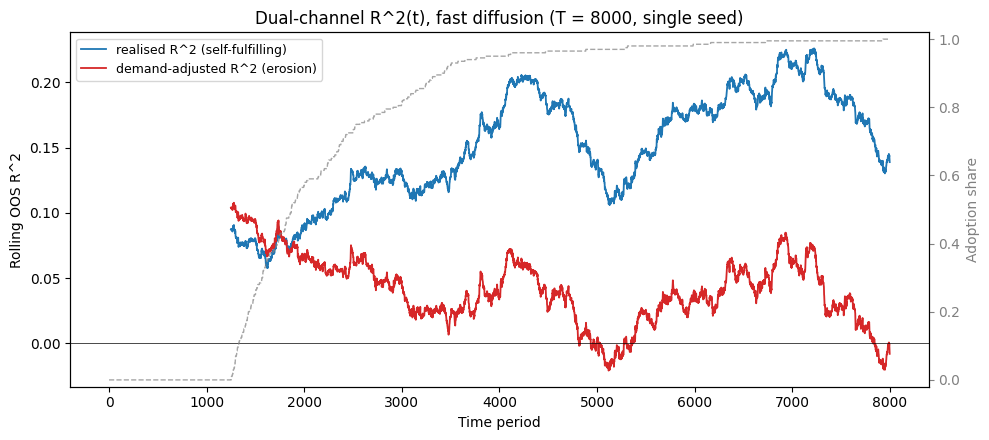

In [7]:
def plot_r2_single_axis(ax, t, r2_realised, r2_da, adoption_share,
                         title, color_realised="C0", color_da="C3"):
    """Single-axis dual-channel R^2(t) plot with adoption share on a twin y-axis.

    Both R^2 readings share the left y-axis; adoption share is plotted on the
    right y-axis as a thin grey line. R^2 NaNs (warm-up) are masked out.
    """
    mask_r = np.isfinite(r2_realised)
    mask_x = np.isfinite(r2_da)
    ax.plot(t[mask_r], r2_realised[mask_r], color=color_realised,
             linewidth=1.3, label="realised R^2 (self-fulfilling)")
    ax.plot(t[mask_x], r2_da[mask_x], color=color_da,
             linewidth=1.3, label="demand-adjusted R^2 (erosion)")
    ax.axhline(0.0, color="k", linewidth=0.5)
    ax.set_xlabel("Time period")
    ax.set_ylabel("Rolling OOS R^2")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)
    ax2 = ax.twinx()
    ax2.plot(t, adoption_share, color="grey", linewidth=1.0,
              linestyle="--", alpha=0.7, label="adoption share")
    ax2.set_ylabel("Adoption share", color="grey")
    ax2.set_ylim(-0.02, 1.02)
    ax2.tick_params(axis="y", colors="grey")
    return ax2


fast_short = next(r for r in results if r["name"] == "fast diffusion")
t_short = np.arange(T)

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_r2_single_axis(
    ax, t_short,
    fast_short["rolling_oos_r2_realised"],
    fast_short["rolling_oos_r2_da"],
    fast_short["adoption_share"],
    f"Dual-channel R^2(t), fast diffusion (T = {T}, single seed)",
)
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_oos_r2_over_time_single.png", dpi=150, bbox_inches="tight")
plt.show()

## Extended horizon: post-saturation behaviour

The short run above ends only a few thousand periods after adoption saturates, so the rolling forecaster is still equilibrating with `phi_effective` when the data ends. The two cells below extend the horizon to `T_long = 30000` periods in the fast-diffusion regime, leaving roughly 25000 periods at A = 1. The question they answer: once adoption has saturated and stayed there for thousands of periods, do the two R^2 readings settle on a stable plateau, or do they continue drifting?

The single-seed plot shows one realisation of the saturated regime in time. The Monte Carlo plot below averages the same trajectory across 50 paired-shock seeds and reports a mean line with +/-1 SD shaded bands, which separates systematic post-saturation behaviour from sampling noise.

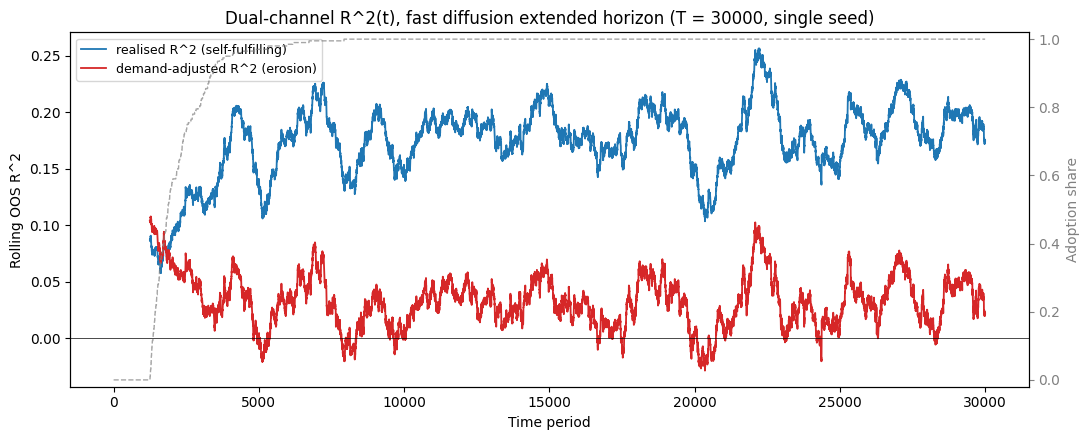

In [8]:
# Single-seed extended-T fast-diffusion run. Reuses the canonical seed so this
# plot is the same realisation as the short-T fast-diffusion line above, just
# continued for an additional 22000 periods past the original horizon.
fast_regime = next(r for r in regimes if r["name"] == "fast diffusion")
rng_long = np.random.default_rng(seed)
out_long = simulate.run(
    T=T_long, N=N, mu=mu, phi=phi,
    sigma_news=sigma_news, sigma_q=sigma_q,
    rng=rng_long,
    forecast_window=forecast_window, forecast_p=forecast_p,
    risk_scale=risk_scale, q_cap=q_cap,
    adoption_pi=fast_regime["pi"], adoption_delta=fast_regime["delta"],
    adoption_start_t=adoption_start_t,
)
demand_adjusted_long = out_long["returns"] - mu * out_long["demand"]
r2_real_long = rolling_oos_r2(out_long["returns"], out_long["forecasts"], eval_window)
r2_da_long = rolling_oos_r2(demand_adjusted_long, out_long["forecasts"], eval_window)
t_long = np.arange(T_long)

fig, ax = plt.subplots(figsize=(11, 4.5))
plot_r2_single_axis(
    ax, t_long, r2_real_long, r2_da_long, out_long["adoption_share"],
    f"Dual-channel R^2(t), fast diffusion extended horizon (T = {T_long}, single seed)",
)
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_oos_r2_saturation_single.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/r9/hz7v9h2s2t7ghxh24dxvgjcw0000gn/T/ipykernel_36563/2740058067.py:26: RuntimeWarning: Mean of empty slice
  mean_r2_real_t = np.nanmean(mc_sat_r2_real, axis=0)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/r9/hz7v9h2s2t7ghxh24dxvgjcw0000gn/T/ipykernel_36563/2740058067.py:28: RuntimeWarning: Mean of empty slice
  mean_r2_da_t = np.nanmean(mc_sat_r2_da, axis=0)


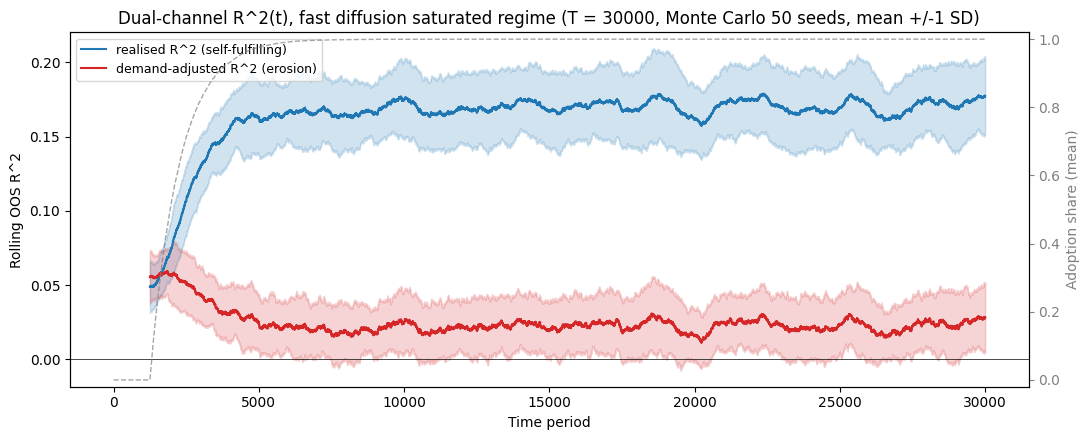

In [9]:
# Monte Carlo across n_seeds_mc_saturation paired-shock seeds, T_long periods,
# fast diffusion only. Stores the per-seed time series and aggregates to a
# mean +/-1 SD band at each time index. The aggregation axis is seeds, not
# adoption-share bins, so the post-saturation tail averages across seeds at
# the *same* point in simulation time.
mc_sat_r2_real = np.full((n_seeds_mc_saturation, T_long), np.nan)
mc_sat_r2_da = np.full((n_seeds_mc_saturation, T_long), np.nan)
mc_sat_A = np.full((n_seeds_mc_saturation, T_long), np.nan)

for s in range(n_seeds_mc_saturation):
    rng_s = np.random.default_rng(mc_saturation_base_seed + s)
    out_s = simulate.run(
        T=T_long, N=N, mu=mu, phi=phi,
        sigma_news=sigma_news, sigma_q=sigma_q,
        rng=rng_s,
        forecast_window=forecast_window, forecast_p=forecast_p,
        risk_scale=risk_scale, q_cap=q_cap,
        adoption_pi=fast_regime["pi"], adoption_delta=fast_regime["delta"],
        adoption_start_t=adoption_start_t,
    )
    demand_adjusted_s = out_s["returns"] - mu * out_s["demand"]
    mc_sat_r2_real[s] = rolling_oos_r2(out_s["returns"], out_s["forecasts"], eval_window)
    mc_sat_r2_da[s] = rolling_oos_r2(demand_adjusted_s, out_s["forecasts"], eval_window)
    mc_sat_A[s] = out_s["adoption_share"]

mean_r2_real_t = np.nanmean(mc_sat_r2_real, axis=0)
std_r2_real_t = np.nanstd(mc_sat_r2_real, axis=0)
mean_r2_da_t = np.nanmean(mc_sat_r2_da, axis=0)
std_r2_da_t = np.nanstd(mc_sat_r2_da, axis=0)
mean_A_t = np.nanmean(mc_sat_A, axis=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
mask_r = np.isfinite(mean_r2_real_t)
mask_x = np.isfinite(mean_r2_da_t)
ax.plot(t_long[mask_r], mean_r2_real_t[mask_r], color="C0", linewidth=1.5,
         label="realised R^2 (self-fulfilling)")
ax.fill_between(t_long[mask_r],
                 mean_r2_real_t[mask_r] - std_r2_real_t[mask_r],
                 mean_r2_real_t[mask_r] + std_r2_real_t[mask_r],
                 color="C0", alpha=0.2)
ax.plot(t_long[mask_x], mean_r2_da_t[mask_x], color="C3", linewidth=1.5,
         label="demand-adjusted R^2 (erosion)")
ax.fill_between(t_long[mask_x],
                 mean_r2_da_t[mask_x] - std_r2_da_t[mask_x],
                 mean_r2_da_t[mask_x] + std_r2_da_t[mask_x],
                 color="C3", alpha=0.2)
ax.axhline(0.0, color="k", linewidth=0.5)
ax.set_xlabel("Time period")
ax.set_ylabel("Rolling OOS R^2")
ax.set_title(
    f"Dual-channel R^2(t), fast diffusion saturated regime "
    f"(T = {T_long}, Monte Carlo {n_seeds_mc_saturation} seeds, mean +/-1 SD)"
)
ax.legend(loc="upper left", fontsize=9)
ax2 = ax.twinx()
ax2.plot(t_long, mean_A_t, color="grey", linewidth=1.0, linestyle="--",
          alpha=0.7, label="mean adoption share")
ax2.set_ylabel("Adoption share (mean)", color="grey")
ax2.set_ylim(-0.02, 1.02)
ax2.tick_params(axis="y", colors="grey")
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_oos_r2_saturation_mc.png", dpi=150, bbox_inches="tight")
plt.show()

## Rolling OOS R^2 versus adoption share, two views

The same forecast evaluated against two distinct targets gives two readings of "is the forecast working?", and they move in opposite directions as adoption rises. Both readings are reported here as separate primary endpoints.

**Realised return view (self-fulfilling channel, section 4.1.1 of the proposal).** R^2 of the forecast against the realised return `r_{t+1}`. This is the metric a deployed forecaster actually computes against observable returns. As adopters trade in the direction of their forecast, contemporaneous demand impact `mu D_t` adds to `r_{t+1}` in the same direction the forecast pointed, so R^2 against realised returns climbs with adoption. This reading answers: does the forecast correctly point at where the realised price goes, including its own contemporaneous price impact?

**Demand-adjusted return view (demand-adjusted-erosion channel, section 4.1.2 of the proposal).** R^2 of the same forecast against the demand-adjusted return `x_{t+1} = r_{t+1} - mu D_t = phi r_t + sigma eps_{t+1}`. The demand-adjusted process has a fixed AR coefficient phi by construction, but the rolling fit picks up the amplified empirical phi_eff from realised returns and over-predicts the demand-adjusted target. R^2 against the demand-adjusted return falls with adoption. This reading answers: after removing the contemporaneous demand impact, does the forecast still carry independent predictive content of the kind it was originally designed to exploit? Note that the demand-adjusted return is a counterfactual, not the full regression residual.

Both quantities come from the same forecast and the same realised path; only the evaluation target differs. Neither view is "wrong"; they answer different questions.

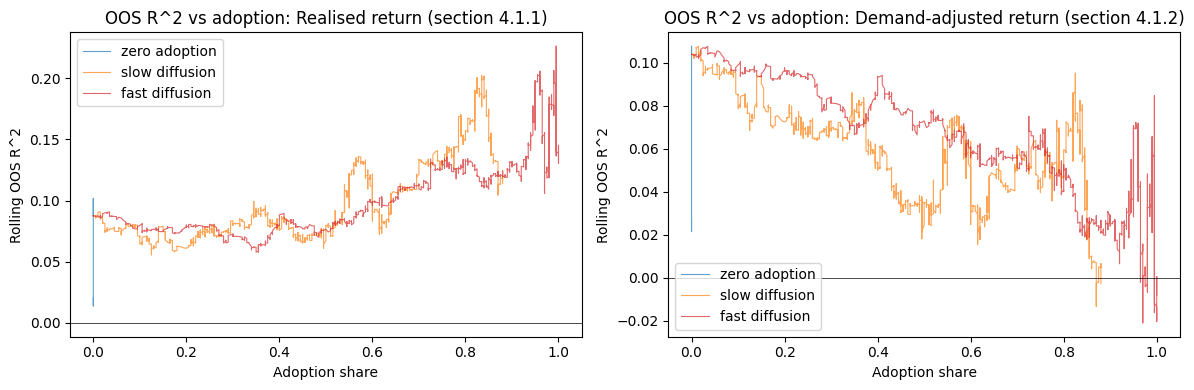

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for r in results:
    a = r["adoption_share"]
    yr = r["rolling_oos_r2_realised"]
    yx = r["rolling_oos_r2_da"]
    mask_r = np.isfinite(yr)
    mask_x = np.isfinite(yx)
    axes[0].plot(a[mask_r], yr[mask_r], color=r["colour"], linewidth=0.8, alpha=0.7, label=r["name"])
    axes[1].plot(a[mask_x], yx[mask_x], color=r["colour"], linewidth=0.8, alpha=0.7, label=r["name"])
for ax, title in zip(axes, ["Realised return (section 4.1.1)", "Demand-adjusted return (section 4.1.2)"]):
    ax.axhline(0.0, color="k", linewidth=0.5)
    ax.set_title(f"OOS R^2 vs adoption: {title}")
    ax.set_xlabel("Adoption share")
    ax.set_ylabel("Rolling OOS R^2")
    ax.legend()
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_oos_r2_vs_adoption.png", dpi=150)
plt.show()

## Rolling effective phi versus adoption share

Same x axis; y is now the rolling lag-1 autocorrelation of returns over the same trailing window. In the implemented return law (6), adopter buying on a positive AR forecast reinforces the lagged-return component through `mu D_t`, so the empirical AR coefficient rises with adoption. This is the mechanical reason the demand-adjusted R^2 falls in the panel above: the rolling fit is over-predicting the underlying phi.

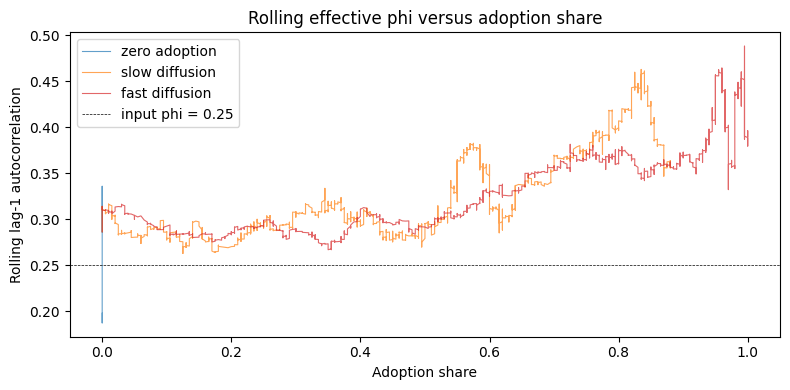

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
for r in results:
    a = r["adoption_share"]
    y = r["rolling_phi"]
    mask = np.isfinite(y)
    ax.plot(a[mask], y[mask], color=r["colour"], linewidth=0.8, alpha=0.7, label=r["name"])
ax.axhline(phi, color="k", linewidth=0.5, linestyle="--", label=f"input phi = {phi}")
ax.set_title("Rolling effective phi versus adoption share")
ax.set_xlabel("Adoption share")
ax.set_ylabel("Rolling lag-1 autocorrelation")
ax.legend()
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_phi_vs_adoption.png", dpi=150)
plt.show()

## Demand contribution to realised returns over time

The realised return decomposition `r_{t+1} = mu D_t + x_{t+1}` splits the realised return into a contemporaneous demand-impact component and a demand-adjusted remainder. The self-fulfilling channel does *not* require `mu D_t` to dominate `r` in variance: it requires `mu D_t` to be *aligned with the forecast*. A small aligned demand push can substantially raise realised R^2 even if its variance share is small, because realised R^2 is sensitive to alignment with the forecast direction, not to total variance.

**Top panel.** Time series of `r_{t+1}` and `mu D_t` for the fast-diffusion regime. The two series live on the same axis; `mu D_t` keeps modest magnitude even at full adoption (the `q_cap = 0.05` per-trader cap is binding), but its sign starts to track the forecast as adopters synchronise.

**Bottom panel.** Rolling Pearson correlation between the public forecast `r_hat_{t+1}^{(A)}` and the demand-impact term `mu D_t`, in a trailing window of length `eval_window`, for all three regimes. This is the direct measure of self-fulfilment alignment. At low adoption the correlation hovers near zero (null demand is uncorrelated with the forecast). As adoption ramps, the correlation rises toward 1.0, because every adopter's order is proportional to the same public forecast. When `corr(r_hat, mu D_t)` rises, the demand channel is delivering a return increment in the forecast's direction, which is exactly the mechanism that lifts realised-return R^2 with adoption.

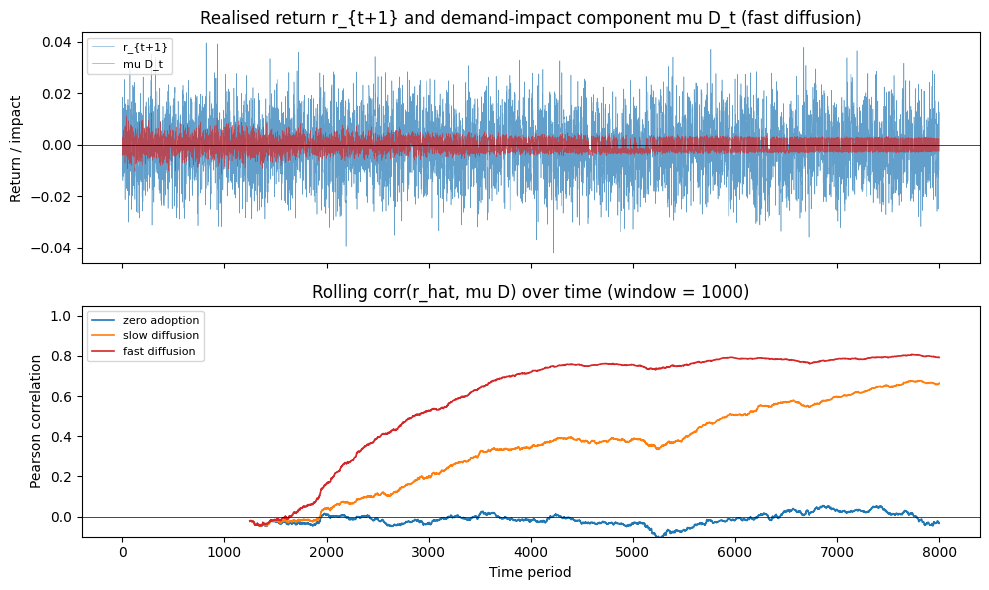

In [12]:
def rolling_corr(x, y, window):
    """Rolling Pearson correlation between x and y over a trailing window.

    Returns NaN where either series is non-finite or the trailing window has
    zero variance. Suitable for streaming forecast/demand pairs.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = x.size
    out = np.full(n, np.nan)
    for i in range(window - 1, n):
        sx = x[i - window + 1 : i + 1]
        sy = y[i - window + 1 : i + 1]
        if not (np.all(np.isfinite(sx)) and np.all(np.isfinite(sy))):
            continue
        vx = sx.var()
        vy = sy.var()
        if vx > 0.0 and vy > 0.0:
            out[i] = float(np.corrcoef(sx, sy)[0, 1])
    return out


fast = next(r for r in results if r["name"] == "fast diffusion")
mu_D_fast = mu * fast["demand"]
r_fast = fast["returns"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(r_fast, color="C0", linewidth=0.4, alpha=0.7, label="r_{t+1}")
axes[0].plot(mu_D_fast, color="C3", linewidth=0.4, alpha=0.7, label="mu D_t")
axes[0].axhline(0.0, color="k", linewidth=0.5)
axes[0].set_title("Realised return r_{t+1} and demand-impact component mu D_t (fast diffusion)")
axes[0].set_ylabel("Return / impact")
axes[0].legend(loc="upper left", fontsize=8)

# Rolling correlation between the public forecast and the demand-impact term,
# regime by regime. This is the alignment-based diagnostic of the
# self-fulfilling channel: it answers "are adopter trades pointing where the
# forecast pointed?", which is what causes realised-R^2 to rise.
corr_window = eval_window
for r in results:
    corr = rolling_corr(r["forecasts"], mu * r["demand"], corr_window)
    axes[1].plot(corr, color=r["colour"], linewidth=1.2, label=r["name"])
axes[1].axhline(0.0, color="k", linewidth=0.5)
axes[1].set_title(f"Rolling corr(r_hat, mu D) over time (window = {corr_window})")
axes[1].set_xlabel("Time period")
axes[1].set_ylabel("Pearson correlation")
axes[1].set_ylim(-0.1, 1.05)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_demand_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Monte Carlo across many seeds

The single-seed plots above are useful for intuition but each curve is one noisy realisation. The proposal's claim is about *expected* behaviour at each adoption share. The cells below repeat the three regimes across 100 paired-shock seeds and bin the post-warm-up rolling metrics by adoption share, then plot the bin mean with a +/-1 SD shaded band. Adoption share is itself a random variable per seed, so each (A_t, metric_t) pair is treated as one observation; pooling across seeds and time gives many observations per adoption-share bin.

In [13]:
num_seeds_mc = 100
mc_base_seed = 1000  # distinct from the single-seed example seed=71

mc_data = {
    regime["name"]: {"A": [], "R2_real": [], "R2_da": [], "phi": []}
    for regime in regimes
}

for s in range(num_seeds_mc):
    seed_s = mc_base_seed + s
    for regime in regimes:
        rng_s = np.random.default_rng(seed_s)
        out_s = simulate.run(
            T=T, N=N, mu=mu, phi=phi,
            sigma_news=sigma_news, sigma_q=sigma_q,
            rng=rng_s,
            forecast_window=forecast_window, forecast_p=forecast_p,
            risk_scale=risk_scale, q_cap=q_cap,
            adoption_pi=regime["pi"], adoption_delta=regime["delta"],
            adoption_start_t=adoption_start_t,
        )
        demand_adjusted_s = out_s["returns"] - mu * out_s["demand"]
        r2r_s = rolling_oos_r2(out_s["returns"], out_s["forecasts"], eval_window)
        r2x_s = rolling_oos_r2(demand_adjusted_s, out_s["forecasts"], eval_window)
        rp_s = rolling_phi(out_s["returns"], eval_window)
        mask = np.isfinite(r2r_s) & np.isfinite(r2x_s) & np.isfinite(rp_s)
        mc_data[regime["name"]]["A"].append(out_s["adoption_share"][mask])
        mc_data[regime["name"]]["R2_real"].append(r2r_s[mask])
        mc_data[regime["name"]]["R2_da"].append(r2x_s[mask])
        mc_data[regime["name"]]["phi"].append(rp_s[mask])

for name in mc_data:
    for key in mc_data[name]:
        mc_data[name][key] = np.concatenate(mc_data[name][key])

print(f"{'regime':<22}{'observations':>13}{'A_min':>9}{'A_max':>9}")
for regime in regimes:
    a = mc_data[regime["name"]]["A"]
    print(f"{regime['name']:<22}{a.size:>13}{a.min():>9.3f}{a.max():>9.3f}")

regime                 observations    A_min    A_max
zero adoption                675100    0.000    0.000
slow diffusion               675100    0.000    0.925
fast diffusion               675100    0.000    1.000


### Mean OOS R^2 vs adoption share with +/-1 SD bands

Both panels overlay all three regimes. The line is the mean R^2 in each adoption-share bin across all seeds and time; the shaded band is +/-1 standard deviation. Bins with fewer than 10 observations are dropped (mostly an issue at the extreme right edge of the slow regime, which the run does not always reach in 8000 periods).

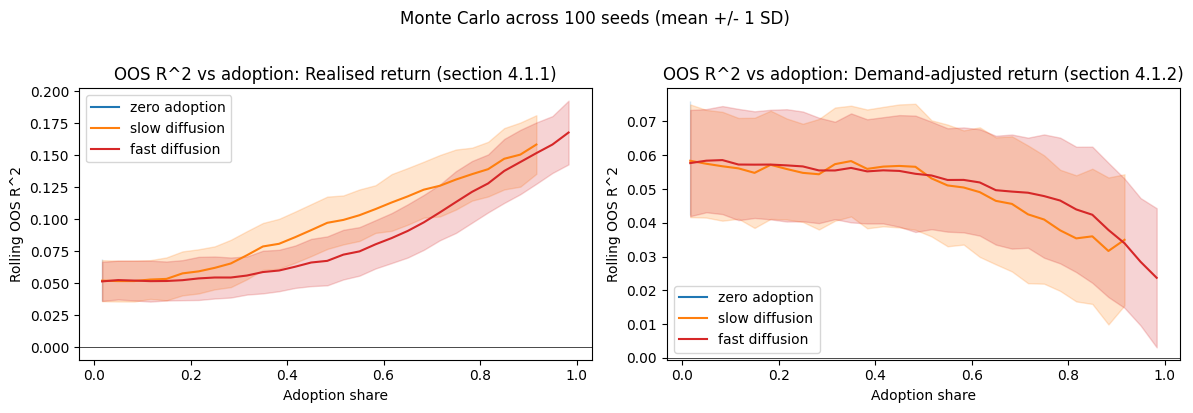

In [14]:
n_bins = 30
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def bin_stats(x, y, edges):
    """Mean and std of y in adoption-share bins of x, plus per-bin counts.

    np.digitize returns ``len(edges)`` for values exactly equal to the
    rightmost edge, so the raw indices have to be clipped into the valid
    bin range. Without this, saturated A = 1.0 observations are silently
    dropped from the final bin, which is most of the fast-diffusion tail.
    """
    inds = np.digitize(x, edges) - 1
    nb = len(edges) - 1
    inds = np.clip(inds, 0, nb - 1)
    means = np.full(nb, np.nan)
    stds = np.full(nb, np.nan)
    counts = np.zeros(nb, dtype=int)
    for i in range(nb):
        m = inds == i
        c = int(m.sum())
        counts[i] = c
        if c > 1:
            means[i] = y[m].mean()
            stds[i] = y[m].std()
    return means, stds, counts


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
panels = [
    (axes[0], "R2_real", "Realised return (section 4.1.1)"),
    (axes[1], "R2_da", "Demand-adjusted return (section 4.1.2)"),
]
for regime in regimes:
    name = regime["name"]
    color = regime["colour"]
    A = mc_data[name]["A"]
    for ax, key, _ in panels:
        m, s, c = bin_stats(A, mc_data[name][key], bin_edges)
        valid = c > 10
        ax.plot(bin_centers[valid], m[valid], color=color, linewidth=1.5, label=name)
        ax.fill_between(bin_centers[valid],
                         m[valid] - s[valid],
                         m[valid] + s[valid],
                         color=color, alpha=0.2)

for ax, _, title in panels:
    ax.axhline(0.0, color="k", linewidth=0.5)
    ax.set_title(f"OOS R^2 vs adoption: {title}")
    ax.set_xlabel("Adoption share")
    ax.set_ylabel("Rolling OOS R^2")
    ax.legend()

fig.suptitle(f"Monte Carlo across {num_seeds_mc} seeds (mean +/- 1 SD)", y=1.02)
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_oos_r2_vs_adoption_mc.png", dpi=150, bbox_inches="tight")
plt.show()

### Mean effective phi vs adoption share with +/-1 SD band

Same binning, applied to the rolling lag-1 autocorrelation of returns. The dashed line is the input phi.

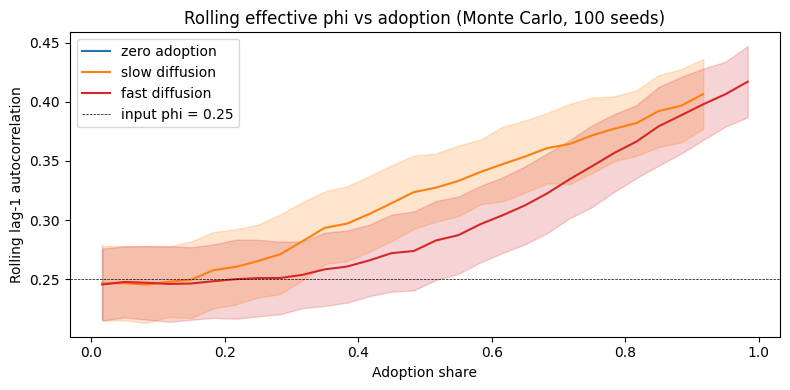

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
for regime in regimes:
    name = regime["name"]
    color = regime["colour"]
    A = mc_data[name]["A"]
    m, s, c = bin_stats(A, mc_data[name]["phi"], bin_edges)
    valid = c > 10
    ax.plot(bin_centers[valid], m[valid], color=color, linewidth=1.5, label=name)
    ax.fill_between(bin_centers[valid],
                     m[valid] - s[valid],
                     m[valid] + s[valid],
                     color=color, alpha=0.2)
ax.axhline(phi, color="k", linewidth=0.5, linestyle="--", label=f"input phi = {phi}")
ax.set_title(f"Rolling effective phi vs adoption (Monte Carlo, {num_seeds_mc} seeds)")
ax.set_xlabel("Adoption share")
ax.set_ylabel("Rolling lag-1 autocorrelation")
ax.legend()
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_04_phi_vs_adoption_mc.png", dpi=150)
plt.show()

## Save numeric summary

Per-regime headline scalars: mean adoption share, mean rolling OOS R^2, and mean rolling effective phi at low-adoption versus high-adoption windows. The full per-period traces are reproducible from the seed; only the headline table goes into the npz.

In [16]:
summary = np.array([r["summary"] for r in results])
regime_pi = np.array([r["pi"] for r in results])
regime_delta = np.array([r["delta"] for r in results])
regime_names = np.array([r["name"] for r in results])

# Summary columns:
# 0: A_low  1: A_high  2: R2_realised_low  3: R2_realised_high
# 4: R2_da_low      5: R2_da_high          6: phi_low  7: phi_high
# Note: R2_da is the demand-adjusted R^2 against x_{t+1} = r_{t+1} - mu D_t
# (counterfactual stripping out the self-fulfilment channel), not the full
# regression residual.
np.savez(
    f"{data_dir}/phase_04_stochastic_adoption.npz",
    summary=summary,
    regime_pi=regime_pi,
    regime_delta=regime_delta,
    regime_names=regime_names,
    phi_input=np.array(phi),
    mu=np.array(mu),
    risk_scale=np.array(risk_scale),
    q_cap=np.array(q_cap),
    forecast_window=np.array(forecast_window),
    eval_window=np.array(eval_window),
    T=np.array(T),
    N=np.array(N),
    seed=np.array(seed),
)

## Done when

- Adoption share trajectories match the three regimes (flat at zero, slow climb, fast saturation).
- Rolling OOS R^2 against realised returns is visibly higher at high adoption than at low adoption (self-fulfilling channel).
- Rolling OOS R^2 against demand-adjusted returns falls with adoption and may turn negative at high adoption (demand-adjusted-erosion channel).
- Rolling effective phi rises with adoption.
- The two R^2 readings come from the same forecast on the same path. Neither is treated as the canonical R^2. They are reported under their own names so the dual-channel result is visible rather than hidden inside a single number.

The 100-seed Monte Carlo bands show that the dual-channel pattern holds in expectation with tight +/-1 SD spreads. Phase 6's threshold maps locate the adoption share at which the demand-adjusted-channel R^2 has eroded below a pre-registered relative threshold; phase 7 turns to net profit and the economic endpoint.